## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
YEAR = 2023
MONTH = 'August'
PERIOD = '1st'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)


In [6]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-08-01,2023,8,2023-08-01,39.662866,22.635299,0.370492,0.034333,-0.427839,-0.034333,0.219168,-0.082988,-0.316662,0.082988,0.079135,0.061730,0.046492,0.061730,NaN,NaN,39.662866,22.635299,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,2023-07-31,39.650181,22.650104,172.699636,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-08-01,2023,8,2023-08-01,39.752697,22.707165,0.354209,0.291871,-0.246103,-0.291871,0.477410,0.303657,-0.365873,-0.303657,0.142033,0.051151,0.134520,0.051151,NaN,NaN,39.752697,22.707165,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,2023-07-31,39.750182,22.750104,238.974574,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-08-01,2023,8,2023-08-01,39.788630,22.729622,0.515865,0.083989,-0.498988,-0.083989,0.424160,0.213616,-0.367591,-0.213616,0.098599,0.044688,0.087157,0.044688,NaN,NaN,39.788630,22.729622,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,2023-07-31,39.750182,22.750104,238.974574,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-08-01,2023,8,2023-08-01,39.662866,22.779030,0.588635,0.235191,-0.518020,-0.235191,0.440729,0.111367,-0.408259,-0.111367,0.083341,0.058407,0.089037,0.058407,NaN,NaN,39.662866,22.779030,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,2023-07-31,39.650181,22.750104,162.692826,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-08-01,2023,8,2023-08-01,39.698798,22.779030,0.538953,0.143744,-0.491663,-0.143744,0.519645,0.124894,-0.488033,-0.124894,0.054584,0.044943,0.037090,0.044943,NaN,NaN,39.698798,22.779030,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,2023-07-31,39.750182,22.750104,238.974574,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0


In [7]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-08-01,2023,8,0.370492,0.034333,-0.427839,-0.034333,0.219168,-0.082988,-0.316662,0.082988,0.079135,0.061730,0.046492,0.061730,NaN,NaN,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,172.699636,0.0,0.0
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-08-01,2023,8,0.354209,0.291871,-0.246103,-0.291871,0.477410,0.303657,-0.365873,-0.303657,0.142033,0.051151,0.134520,0.051151,NaN,NaN,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,238.974574,0.0,0.0
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-08-01,2023,8,0.515865,0.083989,-0.498988,-0.083989,0.424160,0.213616,-0.367591,-0.213616,0.098599,0.044688,0.087157,0.044688,NaN,NaN,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,238.974574,0.0,0.0
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-08-01,2023,8,0.588635,0.235191,-0.518020,-0.235191,0.440729,0.111367,-0.408259,-0.111367,0.083341,0.058407,0.089037,0.058407,NaN,NaN,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,162.692826,0.0,0.0
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-08-01,2023,8,0.538953,0.143744,-0.491663,-0.143744,0.519645,0.124894,-0.488033,-0.124894,0.054584,0.044943,0.037090,0.044943,NaN,NaN,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,238.974574,0.0,0.0


In [11]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-08-01,αγιας,θεσσαλιας,22.750267,39.710970,2023.0,8.0,0.504676,0.184783,-0.455058,-0.184783,0.480495,0.183731,-0.431407,-0.183731,0.083756,0.050454,0.071820,0.050454,NaN,NaN,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,211.711384,0.0,0.0
1,2023-08-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2023.0,8.0,0.472622,0.111141,-0.446070,-0.111141,0.456914,0.096210,-0.432481,-0.096210,0.063769,0.058472,0.035170,0.058472,NaN,NaN,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,314.133211,0.0,0.0
2,2023-08-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2023.0,8.0,0.405488,0.032937,-0.376530,-0.032937,0.414660,0.039871,-0.375798,-0.039871,0.027351,0.038605,0.015157,0.038605,NaN,NaN,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,204.246283,0.0,0.0
3,2023-08-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2023.0,8.0,0.656492,0.350661,-0.534098,-0.350661,0.604800,0.294615,-0.501389,-0.294615,0.046175,0.055259,0.028865,0.055259,NaN,NaN,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,201.881806,0.0,0.0
4,2023-08-01,βολου,θεσσαλιας,22.883800,39.351977,2023.0,8.0,0.398398,0.038744,-0.389705,-0.038744,0.375690,0.026398,-0.371939,-0.026398,0.041397,0.037417,0.027065,0.037417,NaN,NaN,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,208.555492,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-08-01,τεμπων,θεσσαλιας,22.553160,39.852112,2023.0,8.0,0.501045,0.127962,-0.462019,-0.127962,0.494594,0.117515,-0.453937,-0.117515,0.059609,0.062963,0.034723,0.062963,NaN,NaN,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,155.597145,0.0,0.0
21,2023-08-01,τρικκαιων,θεσσαλιας,21.797560,39.635058,2023.0,8.0,0.451681,0.050418,-0.457180,-0.050418,0.435101,0.031466,-0.447723,-0.031466,0.066011,0.060949,0.039491,0.060949,NaN,NaN,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,296.693971,0.0,0.0
22,2023-08-01,τυρναβου,θεσσαλιας,22.343000,39.828472,2023.0,8.0,0.479748,0.099030,-0.465198,-0.099030,0.452282,0.092872,-0.426375,-0.092872,0.076410,0.074815,0.074628,0.074815,NaN,NaN,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,124.964158,0.0,0.0
23,2023-08-01,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2023.0,8.0,0.364534,-0.015631,-0.398823,0.015631,0.409016,0.033867,-0.424689,-0.033867,0.066191,0.064942,0.037878,0.064942,NaN,NaN,14179.025000,13814.481685,14325.770833,13813.812500,14609.167725,14019.155400,14719.909041,14095.839286,233.073064,0.0,0.0


In [12]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [13]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [14]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [15]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [16]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [17]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [18]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [19]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

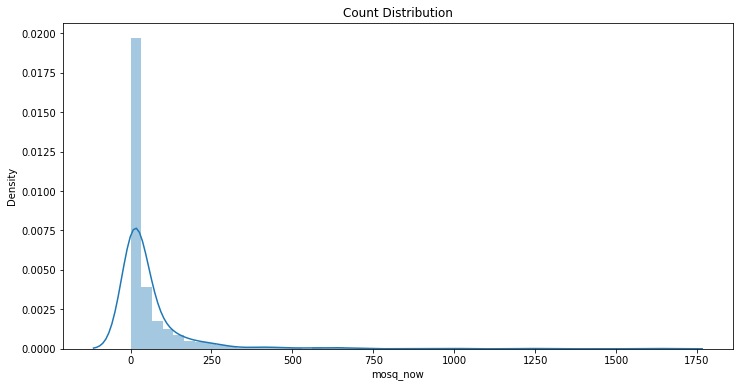

In [20]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [21]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

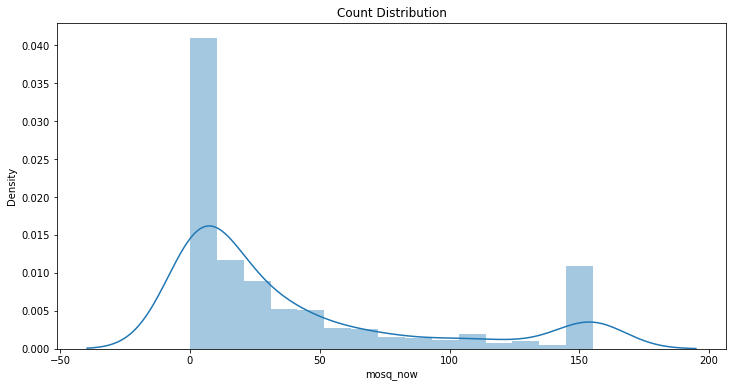

In [22]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

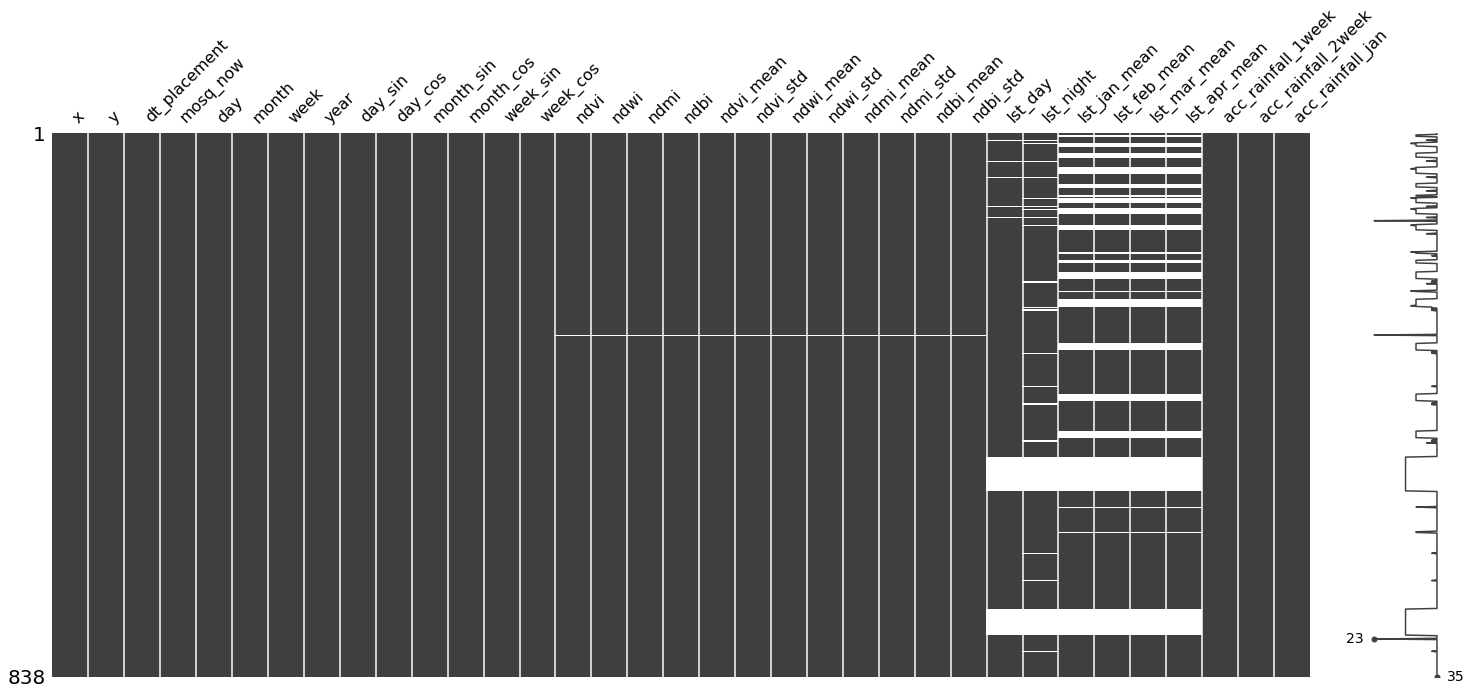

In [23]:
missingno.matrix(mosquito_data_nuts2)

In [24]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [25]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

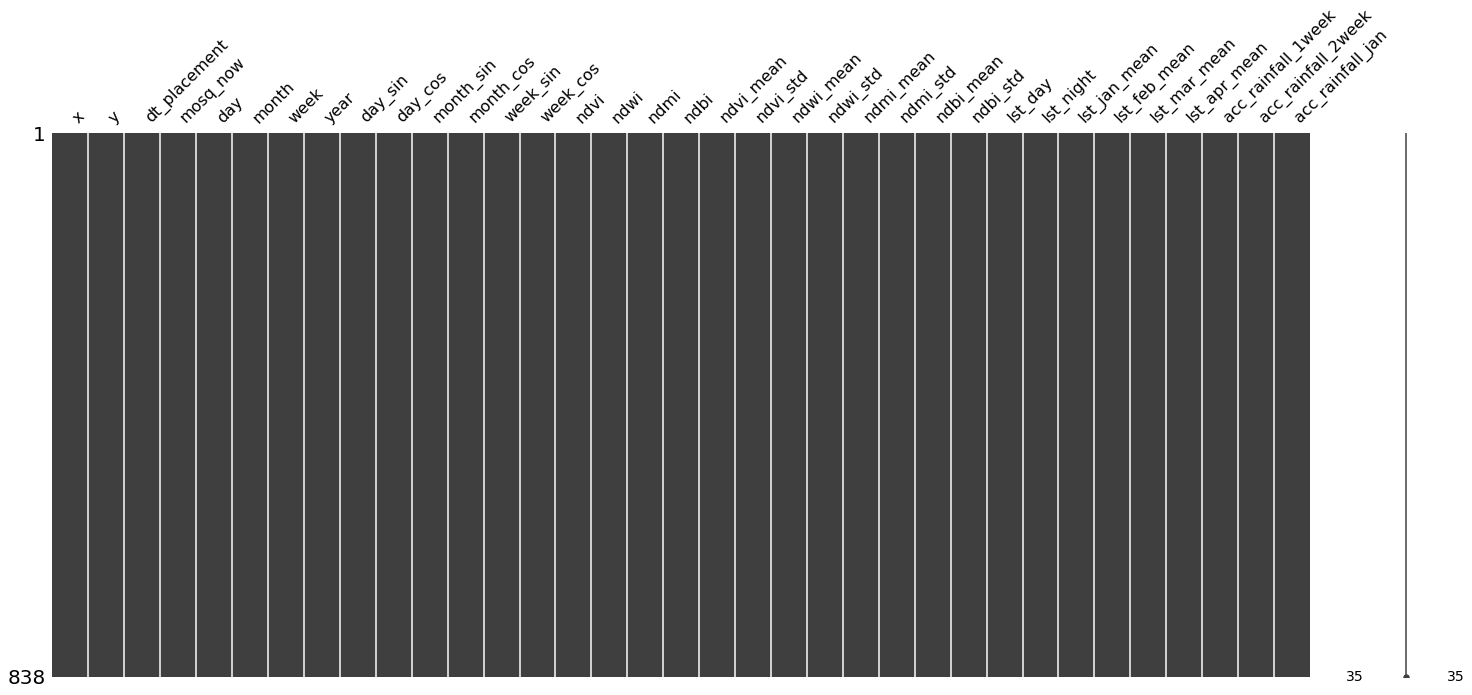

In [26]:
missingno.matrix(mosquito_data_nuts2)

In [27]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [28]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


In [29]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 39.28648 | Val Loss: 28.77484 | Train Acc: 3.759| Val Acc: 3.381
Epoch 002: | Train Loss: 34.95422 | Val Loss: 27.16044 | Train Acc: 3.263| Val Acc: 3.073
Epoch 003: | Train Loss: 34.01359 | Val Loss: 26.78813 | Train Acc: 2.949| Val Acc: 2.842
Epoch 004: | Train Loss: 33.45127 | Val Loss: 26.17742 | Train Acc: 2.790| Val Acc: 2.625
Epoch 005: | Train Loss: 33.14514 | Val Loss: 25.40930 | Train Acc: 2.721| Val Acc: 2.591
Epoch 006: | Train Loss: 32.74699 | Val Loss: 24.59232 | Train Acc: 2.618| Val Acc: 2.572
Epoch 007: | Train Loss: 32.76309 | Val Loss: 24.18824 | Train Acc: 2.637| Val Acc: 2.389
Epoch 008: | Train Loss: 32.45926 | Val Loss: 24.40271 | Train Acc: 2.642| Val Acc: 2.391
Epoch 009: | Train Loss: 32.19642 | Val Loss: 24.54254 | Train Acc: 2.583| Val Acc: 2.366
Epoch 010: | Train Loss: 32.19447 | Val Loss: 24.66978 | Train Acc: 2.608| Val Acc: 2.170
Epoch 011: | Train Loss: 32.05617 | Val Loss: 23.99367 | Train Acc: 2.583| Val Acc: 1.830
Epoch 012:

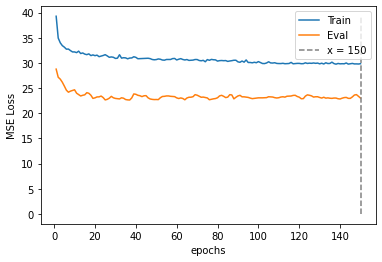

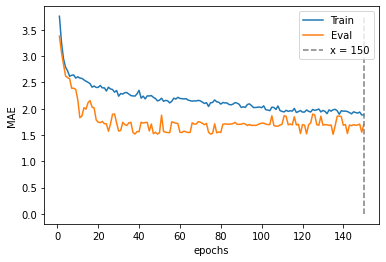

In [30]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [31]:
metrics(train, test, threshold=30)

MAE on train set:  23.341497555562004
min prediction: 1
max prediction: 188

MAE on test set:  26.91374020037393
Error ⩽ 30: 70.99 %
min prediction: 1
max prediction: 268


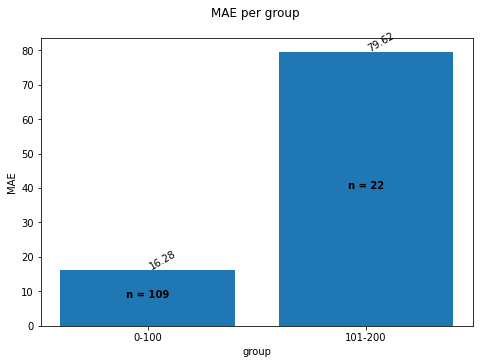

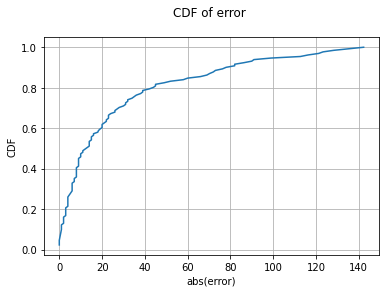

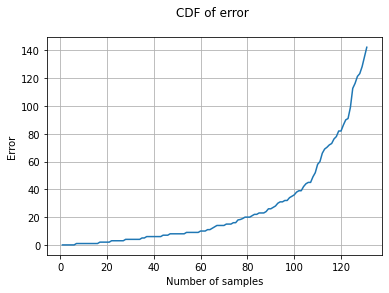

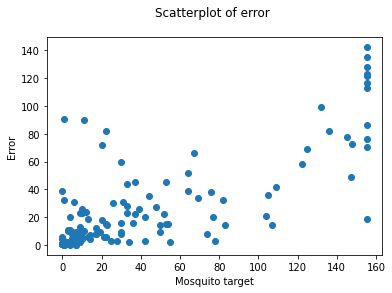

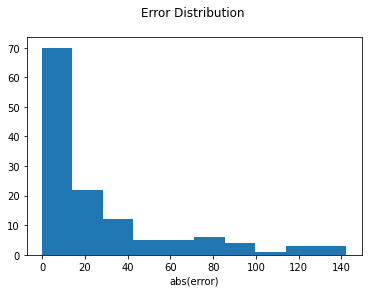

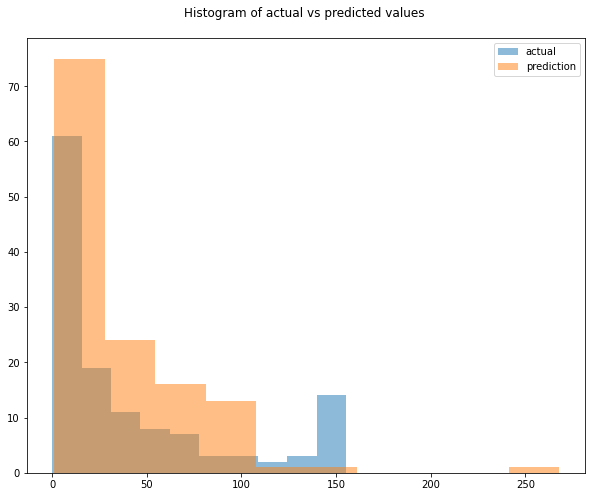

In [32]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.65694 | Val Loss: 0.04772 | Train Acc: 2.371| Val Acc: 0.045
Epoch 002: | Train Loss: 32.98158 | Val Loss: 0.05456 | Train Acc: 2.231| Val Acc: 0.045
Epoch 003: | Train Loss: 33.12640 | Val Loss: 0.00126 | Train Acc: 2.281| Val Acc: 0.045
Epoch 004: | Train Loss: 32.73006 | Val Loss: 0.00395 | Train Acc: 2.198| Val Acc: 0.045
Epoch 005: | Train Loss: 32.71576 | Val Loss: 0.00020 | Train Acc: 2.198| Val Acc: 0.045
Epoch 006: | Train Loss: 32.78652 | Val Loss: 0.00995 | Train Acc: 2.187| Val Acc: 0.045
Epoch 007: | Train Loss: 32.79445 | Val Loss: 0.03432 | Train Acc: 2.209| Val Acc: 0.045
Epoch 008: | Train Loss: 32.70264 | Val Loss: 0.17198 | Train Acc: 2.239| Val Acc: 0.045
Epoch 009: | Train Loss: 32.53127 | Val Loss: 0.00562 | Train Acc: 2.215| Val Acc: 0.045
Epoch 010: | Train Loss: 32.51425 | Val Loss: 0.22882 | Train Acc: 2.194| Val Acc: 0.045
Epoch 011: | Train Loss: 32.40534 | Val Loss: 0.14858 | Train Acc: 2.171| Val Acc: 0.045
Epoch 012: | Train Lo

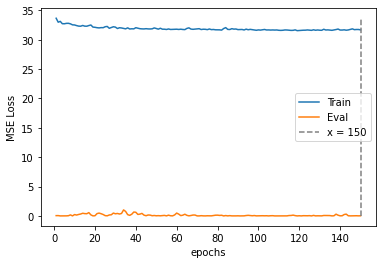

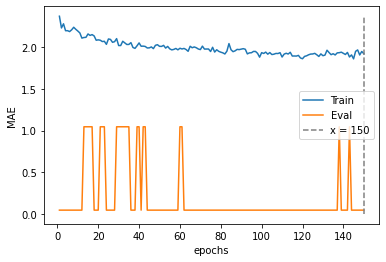

In [33]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [34]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [35]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [36]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [37]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [38]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [39]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

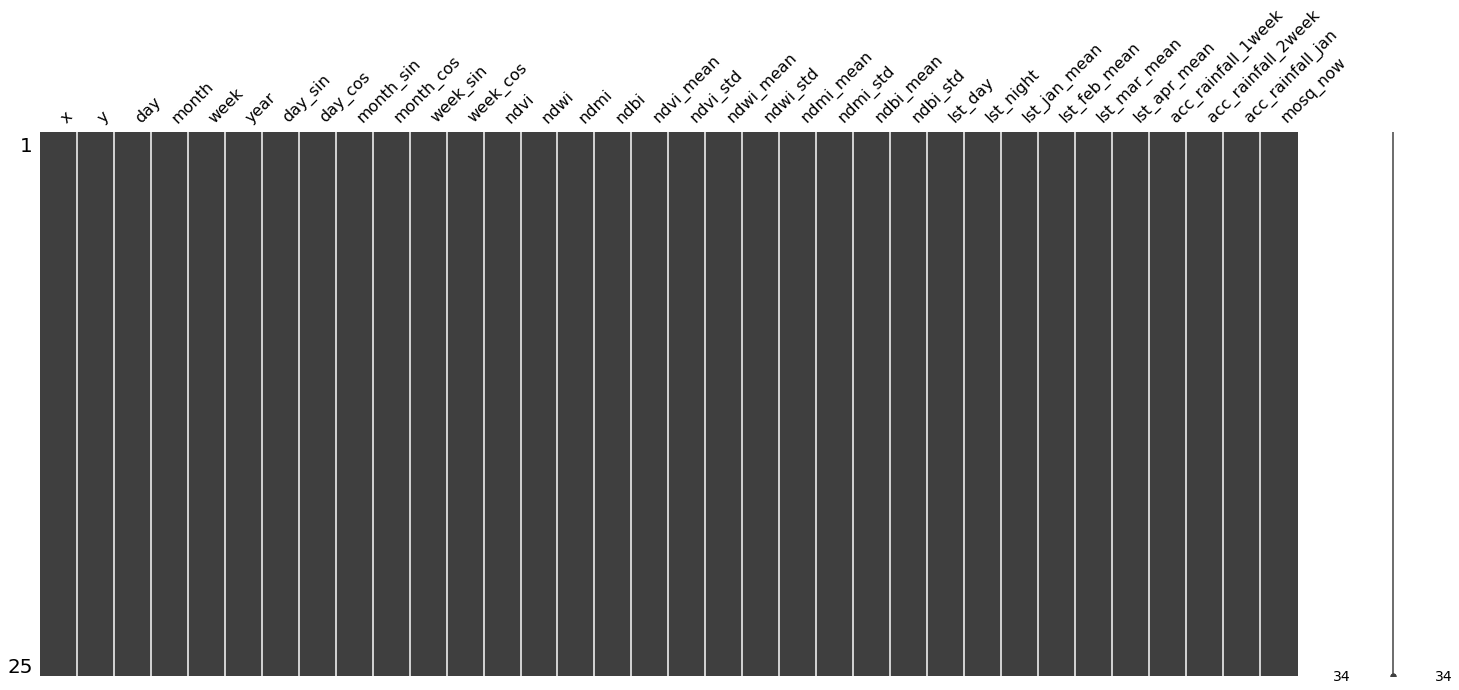

In [40]:
missingno.matrix(dataset_mamoth)

In [41]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [42]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [43]:
predictions = give_predictions(model, dataset_mamoth)

In [44]:
mosqutio_predictions['mosq_pred'] = predictions

In [45]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2023-08-01,49
1,22.692366,39.136391,2023-08-01,41
2,24.073790,39.328960,2023-08-01,38
3,21.430513,39.221380,2023-08-01,54
4,22.883800,39.351977,2023-08-01,100
...,...,...,...,...
20,22.553160,39.852112,2023-08-01,143
21,21.797560,39.635058,2023-08-01,193
22,22.343000,39.828472,2023-08-01,168
23,22.020557,39.603750,2023-08-01,204


In [46]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_{YEAR}-{MONTH}-{PERIOD}.csv', index = False)